In [36]:
import numpy as np
import pandas as pd
import sklearn as sk
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.preprocessing import RobustScaler
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

Data Exploration and Preprocessing


In [37]:
data = pd.read_csv('data/AABA_2006-01-01_to_2018-01-01.csv')
data.describe()

,Open,High,Low,Close,Volume
count,3019.000000,3019.000000,3019.000000,3019.000000,3.019000e+03
mean,28.426479,28.766532,28.066558,28.412726,2.158391e+07
std,13.257242,13.356692,13.157326,13.258163,1.926231e+07
min,9.100000,9.480000,8.940000,8.950000,1.939061e+06
25%,16.175000,16.385000,15.970000,16.130000,1.248025e+07
50%,27.180000,27.490000,26.820000,27.100000,1.732130e+07
75%,36.655000,37.035000,36.305000,36.635000,2.512757e+07
max,73.020000,73.250000,72.460000,72.930000,4.382317e+08


In [38]:
index_fund_data = pd.read_csv('data/SPX.csv')
index_fund_data = index_fund_data[index_fund_data['Date'] > '2010-01-01']
index_fund_data['Date'] = pd.to_datetime(index_fund_data['Date'])
index_fund_data.drop(columns=['Adj Close'], inplace=True)
data = data.bfill()

In [39]:
data.head(5)

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
1,2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2,2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
3,2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
4,2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


In [40]:
data = data[data['Date'] > '2010-01-01']
data = data.reset_index(drop=True)
data.head(5)

,Date,Open,High,Low,Close,Volume,Name
0,2010-01-04,16.94,17.20,16.88,17.10,16588957,AABA
1,2010-01-05,17.22,17.23,17.00,17.23,11718126,AABA
2,2010-01-06,17.17,17.30,17.07,17.17,16421960,AABA
3,2010-01-07,16.81,16.90,16.57,16.70,31816301,AABA
4,2010-01-08,16.68,16.76,16.62,16.70,15471074,AABA


In [41]:
data['Date'] = pd.to_datetime(data['Date'])
data = data.bfill()
data.describe()

,Date,Open,High,Low,Close,Volume
count,2012,2012.000000,2012.000000,2012.000000,2012.00000,2.012000e+03
mean,2014-01-01 16:56:18.131212,30.941456,31.277594,30.599210,30.93997,1.888270e+07
min,2010-01-04 00:00:00,11.300000,11.800000,11.090000,11.09000,1.939061e+06
25%,2012-01-02 00:00:00,16.190000,16.400000,16.000000,16.14750,1.097719e+07
50%,2014-01-02 12:00:00,32.050000,32.560000,31.560000,32.13500,1.545990e+07
75%,2016-01-01 00:00:00,40.910000,41.272500,40.425000,40.93000,2.218065e+07
max,2017-12-29 00:00:00,73.020000,73.250000,72.460000,72.93000,2.693771e+08
std,NaN,14.818074,14.945141,14.689174,14.81872,1.523157e+07


In [42]:
# Drop old index columns if they exist
for col in ['index_open', 'index_high', 'index_low', 'index_close', 'index_volume']:
    if col in data.columns:
        data = data.drop(columns=col)

# Rename and merge
index_renamed = index_fund_data.rename(
    columns={
        'Open': 'index_open',
        'High': 'index_high',
        'Low': 'index_low',
        'Close': 'index_close',
        'Volume': 'index_volume'
    }
)
data = data.merge(index_renamed, on='Date', how='left')
data.head()

,Date,Open,High,Low,Close,Volume,Name,index_open,index_high,index_low,index_close,index_volume
0,2010-01-04,16.94,17.20,16.88,17.10,16588957,AABA,1116.560059,1133.869995,1116.560059,1132.989990,3991400000
1,2010-01-05,17.22,17.23,17.00,17.23,11718126,AABA,1132.660034,1136.630005,1129.660034,1136.520020,2491020000
2,2010-01-06,17.17,17.30,17.07,17.17,16421960,AABA,1135.709961,1139.189941,1133.949951,1137.140015,4972660000
3,2010-01-07,16.81,16.90,16.57,16.70,31816301,AABA,1136.270020,1142.459961,1131.319946,1141.689941,5270680000
4,2010-01-08,16.68,16.76,16.62,16.70,15471074,AABA,1140.520020,1145.390015,1136.219971,1144.979980,4389590000


In [43]:
data.shape

(2012, 12)

Split into Train, Test, and Validation Sets

In [44]:
cv_splits = TimeSeriesSplit(n_splits=5)

In [45]:
iso_param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'max_features': [0.5, 0.8, 1.0],
    'contamination': [0.001, 0.005, 0.01, 0.02]
}

rf_param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

Feature Engineering

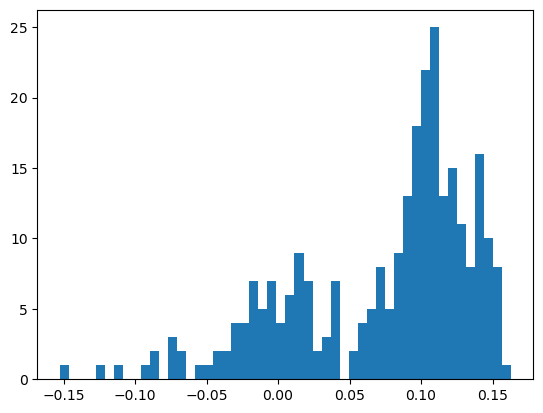

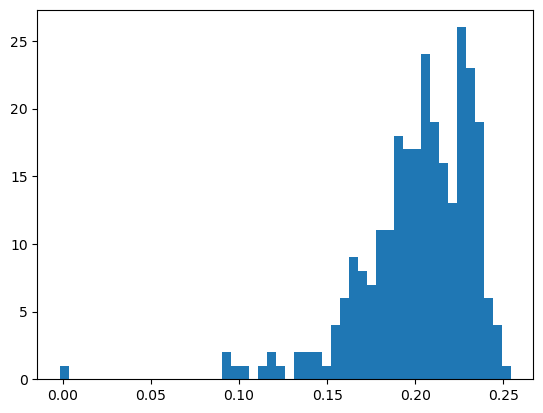

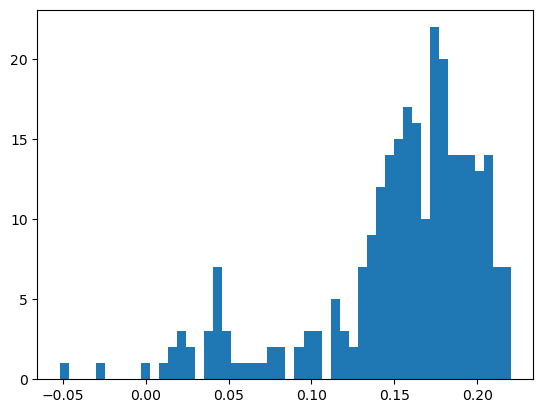

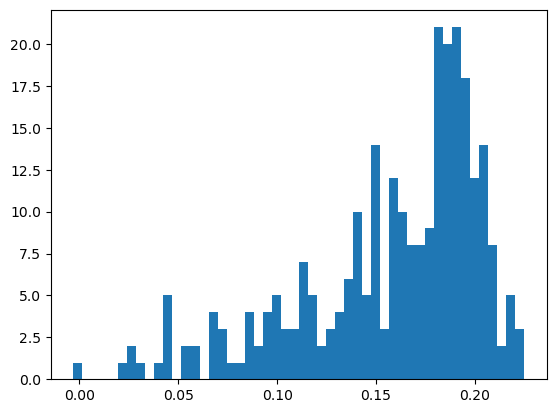

/opt/anaconda3/envs/mse446/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


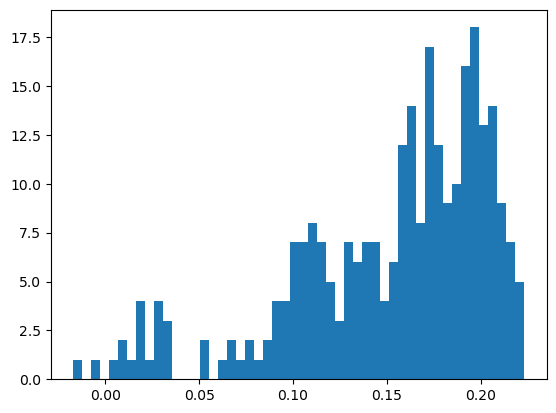

In [46]:
# --- Cross Validation Loop (minimal changes, clearer) ---
cv_iso_train_recall = []
cv_iso_val_recall = []
cv_iso_train_precision = []
cv_iso_val_precision = []

cv_rf_train_recall = []
cv_rf_val_recall = []
cv_rf_train_precision = []
cv_rf_val_precision = []

threshold = 3  # z-score threshold for anomalies

for train_idx, val_idx in cv_splits.split(data):
    X_train = data.iloc[train_idx].copy()
    X_val = data.iloc[val_idx].copy() 
     
    # --- Feature Engineering ---
    for df in [X_train, X_val]:
        df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
        df['excess_return'] = df['log_return'] - np.log(df['index_close'] / df['index_close'].shift(1))
        df['vol_5'] = df['log_return'].rolling(5).std()
        df['vol_20'] = df['log_return'].rolling(20).std()
        df['vol_60'] = df['log_return'].rolling(60).std()
        df['range_vol'] = (df['High'] - df['Low']) / df['Close']
        df['vol_mean'] = df['Volume'].rolling(20).mean()
        df['vol_std'] = df['Volume'].rolling(20).std()
        df['volume_z'] = (df['Volume'] - df['vol_mean']) / df['vol_std']
    
    # --- Label Generation ---
    mean_excess = X_train['excess_return'].mean()
    std_excess = X_train['excess_return'].std()
    
    
    y_train = ( (X_train['excess_return'] - mean_excess).abs() / std_excess > threshold ).astype(int)
    y_val   = ( (X_val['excess_return'] - mean_excess).abs() / std_excess > threshold ).astype(int)
    
    # Drop NaNs caused by rolling windows
    X_train = X_train.dropna()
    X_val = X_val.dropna()
    y_train = y_train.loc[X_train.index]
    y_val = y_val.loc[X_val.index]
    
    # Select features
    features = ['log_return','vol_5','vol_20','vol_60','range_vol','vol_mean','vol_std','volume_z']
    X_train = X_train[features]
    X_val = X_val[features]
    
    # Scale
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # --- Isolation Forest ---
    best_iso_score = -np.inf
    best_iso_model = None
    for params in ParameterGrid(iso_param_grid):
        model = IsolationForest(random_state=42, **params)
        model.fit(X_train_scaled)
        pred_val = (model.predict(X_val_scaled) == -1).astype(int)
        score = recall_score(y_val, pred_val)
        if score > best_iso_score:
            best_iso_score = score
            best_iso_model = model
    
    pred_iso_train = (best_iso_model.predict(X_train_scaled) == -1).astype(int)
    pred_iso_val = (best_iso_model.predict(X_val_scaled) == -1).astype(int)
    
    cv_iso_train_recall.append(recall_score(y_train, pred_iso_train))
    cv_iso_val_recall.append(recall_score(y_val, pred_iso_val))
    cv_iso_train_precision.append(precision_score(y_train, pred_iso_train))
    cv_iso_val_precision.append(precision_score(y_val, pred_iso_val))
    
    # --- Random Forest ---
    best_rf_score = -np.inf
    best_rf_model = None
    for params in ParameterGrid(rf_param_grid):
        model = RandomForestClassifier(random_state=42, **params)
        model.fit(X_train_scaled, y_train)
        pred_val = model.predict(X_val_scaled)
        score = recall_score(y_val, pred_val)
        if score > best_rf_score:
            best_rf_score = score
            best_rf_model = model

    plt.hist(best_iso_model.decision_function(X_val_scaled), bins=50)
    plt.show()
    
    pred_rf_train = best_rf_model.predict(X_train_scaled)
    pred_rf_val = best_rf_model.predict(X_val_scaled)
    
    cv_rf_train_recall.append(recall_score(y_train, pred_rf_train))
    cv_rf_val_recall.append(recall_score(y_val, pred_rf_val))
    cv_rf_train_precision.append(precision_score(y_train, pred_rf_train))
    cv_rf_val_precision.append(precision_score(y_val, pred_rf_val))

In [47]:
print("ISO CV TRAIN SCORES:")
print(f"Recall: {cv_iso_train_recall}, Avg: {np.mean(cv_iso_train_recall)}")
print(f"Precision: {cv_iso_train_precision}, Avg: {np.mean(cv_iso_train_precision)}")
print("\nISO CV VAL SCORES:")
print(f"Recall: {cv_iso_val_recall}, Avg: {np.mean(cv_iso_val_recall)}")
print(f"Precision: {cv_iso_val_precision}, Avg: {np.mean(cv_iso_val_precision)}")

print("\nRF CV TRAIN SCORES:")
print(f"Recall: {cv_rf_train_recall}, Avg: {np.mean(cv_rf_train_recall)}")
print(f"Precision: {cv_rf_train_precision}, Avg: {np.mean(cv_rf_train_precision)}")
print("\nRF CV VAL SCORES:")
print(f"Recall: {cv_rf_val_recall}, Avg: {np.mean(cv_rf_val_recall)}")
print(f"Precision: {cv_rf_val_precision}, Avg: {np.mean(cv_rf_val_precision)}")

ISO CV TRAIN SCORES:
Recall: [0.4, 0.25, 0.4375, 0.4090909090909091, 0.2857142857142857], Avg: 0.3564610389610389
Precision: [0.6666666666666666, 0.75, 0.3684210526315789, 0.34615384615384615, 0.47058823529411764], Avg: 0.5203659601492419

ISO CV VAL SCORES:
Recall: [0.9090909090909091, 1.0, 0.1111111111111111, 0.2, 0.5], Avg: 0.5440404040404041
Precision: [0.22727272727272727, 1.0, 0.3333333333333333, 1.0, 0.5], Avg: 0.6121212121212121

RF CV TRAIN SCORES:
Recall: [1.0, 1.0, 1.0, 1.0, 1.0], Avg: 1.0
Precision: [1.0, 1.0, 1.0, 1.0, 1.0], Avg: 1.0

RF CV VAL SCORES:
Recall: [0.2727272727272727, 1.0, 0.3333333333333333, 0.0, 1.0], Avg: 0.5212121212121212
Precision: [0.6, 1.0, 1.0, 0.0, 1.0], Avg: 0.72
